# Modélisation et décision

Les deux notebooks précédents ont nettoyé les données et vérifié que le
nettoyage servait à quelque chose. Celui-ci va jusqu'au bout de la chaîne :
d'un score de risque à une **décision de refus**, puis au **coût** de cette
décision.

C'est le passage qui manque le plus souvent aux projets de classification. Un
modèle qui produit une probabilité ne décide rien : il faut encore fixer un
seuil, et ce choix n'est pas statistique, il est économique.

---

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

sys.path.insert(0, str(Path("..").resolve()))
warnings.filterwarnings("ignore")

PROCESSED = Path("../data/processed")
FIGS = Path("../reports/figures")
CIBLE = "SeriousDlqin2yrs"
HASARD = 0

BLEU, ORANGE, GRIS, TRAIT = "#2a78d6", "#eb6834", "#898781", "#c3c2b7"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "xtick.color": "#898781", "ytick.color": "#898781", "font.size": 9,
    "grid.color": "#e1e0d9",
})
virgule = FuncFormatter(lambda v, _: f"{v:.2f}".replace(".", ","))


def save_fig(fig, nom):
    chemin = FIGS / f"{nom}.png"
    fig.savefig(chemin, dpi=150, bbox_inches="tight", facecolor="white")
    return chemin

In [2]:
train = pd.read_parquet(PROCESSED / "train.parquet")
val = pd.read_parquet(PROCESSED / "val.parquet")

X_train, y_train = train.drop(columns=CIBLE), train[CIBLE]
X_val, y_val = val.drop(columns=CIBLE), val[CIBLE]

N_DEFAUTS = int(y_val.sum())
N_SAINS = int((y_val == 0).sum())
print(f"Entraînement : {len(X_train):,} dossiers".replace(",", " "))
print(f"Validation   : {len(X_val):,} dossiers — {N_DEFAUTS:,} défauts, {N_SAINS:,} sains".replace(",", " "))

Entraînement : 105 000 dossiers
Validation   : 45 000 dossiers — 3 008 défauts  41 992 sains


## 1. Régler le modèle, sans y passer la semaine

Une recherche aléatoire sur huit configurations suffit ici. Le réglage fin des
hyperparamètres est ce qui rapporte le moins sur un jeu tabulaire propre : on
gagne quelques millièmes d'AUC, là où le traitement des codes de saisie en
valait cent cinquante. Autant le faire sobrement et passer au reste.

La recherche est validée en trois plis **sur l'entraînement uniquement** : le
jeu de validation ne doit servir qu'une fois, à la fin.

In [3]:
grille = {
    "n_estimators": [300, 600, 900],
    "learning_rate": [0.02, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "min_child_samples": [20, 100, 300],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "reg_lambda": [0, 1, 10],
}

recherche = RandomizedSearchCV(
    LGBMClassifier(random_state=HASARD, verbose=-1, n_jobs=4, subsample_freq=1),
    grille,
    n_iter=8,
    scoring="roc_auc",
    cv=StratifiedKFold(3, shuffle=True, random_state=HASARD),
    random_state=HASARD,
    n_jobs=1,
    refit=True,
)
recherche.fit(X_train, y_train)

modele = recherche.best_estimator_
print(f"AUC en validation croisée : {recherche.best_score_:.4f}")
pd.Series(recherche.best_params_).to_frame("valeur retenue")

AUC en validation croisée : 0.8644


,valeur retenue
subsample,1.00
reg_lambda,10.00
num_leaves,15.00
n_estimators,300.00
min_child_samples,100.00
learning_rate,0.05
colsample_bytree,1.00


In [4]:
p_val = modele.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, p_val)
ap = average_precision_score(y_val, p_val)

print(f"AUC sur le jeu de validation          : {auc:.4f}")
print(f"Précision moyenne (aire sous la PR)   : {ap:.4f}")
print(f"Précision d'un modèle au hasard       : {y_val.mean():.4f}")

AUC sur le jeu de validation          : 0.8671
Précision moyenne (aire sous la PR)   : 0.4048
Précision d'un modèle au hasard       : 0.0668


Le réglage rapporte **+0,0023 d'AUC** (0,8648 sans réglage, 0,8671 après). Le
chiffre est dérisoire comparé aux 0,153 gagnés au nettoyage, et il confirme
l'ordre des priorités : la qualité des données pèse bien plus lourd que les
hyperparamètres. La recherche a d'ailleurs retenu une configuration
**prudente** — 15 feuilles, 300 arbres, régularisation à 10 — donc un modèle
plus simple que la valeur par défaut.

L'AUC en validation croisée (0,8644) et sur le jeu de validation (0,8671) sont
proches : pas de surajustement au réglage.

La **précision moyenne** mérite plus d'attention que l'AUC. À 0,405 contre
0,067 pour un modèle au hasard, elle dit que le modèle est **six fois** plus
efficace que le tirage aléatoire pour concentrer les vrais défauts en tête de
classement. C'est cette grandeur-là qui se dégrade vite quand les positifs sont
rares, donc celle qui mérite d'être surveillée.

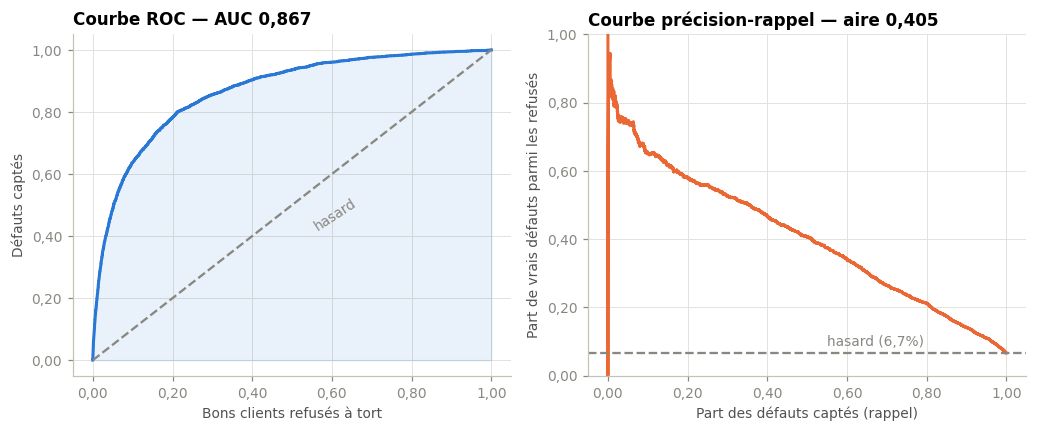

In [5]:
fpr, tpr, _ = roc_curve(y_val, p_val)
precision, rappel, _ = precision_recall_curve(y_val, p_val)

fig, (g, d) = plt.subplots(1, 2, figsize=(9.5, 4))

g.plot(fpr, tpr, color=BLEU, lw=2)
g.fill_between(fpr, tpr, color=BLEU, alpha=0.10)
g.plot([0, 1], [0, 1], color=GRIS, lw=1.5, ls="--")
g.text(0.55, 0.42, "hasard", color=GRIS, fontsize=9, rotation=33)
g.set_xlabel("Bons clients refusés à tort")
g.set_ylabel("Défauts captés")
g.set_title(f"Courbe ROC — AUC {auc:.3f}".replace(".", ","))
g.xaxis.set_major_formatter(virgule)
g.yaxis.set_major_formatter(virgule)
g.grid(lw=0.6)
g.set_axisbelow(True)

d.plot(rappel, precision, color=ORANGE, lw=2)
d.axhline(y_val.mean(), color=GRIS, lw=1.5, ls="--")
d.text(0.55, y_val.mean() + 0.02, f"hasard ({y_val.mean():.1%})".replace(".", ","),
       color=GRIS, fontsize=9)
d.set_xlabel("Part des défauts captés (rappel)")
d.set_ylabel("Part de vrais défauts parmi les refusés")
d.set_title(f"Courbe précision-rappel — aire {ap:.3f}".replace(".", ","))
d.set_ylim(0, 1)
d.xaxis.set_major_formatter(virgule)
d.yaxis.set_major_formatter(virgule)
d.grid(lw=0.6)
d.set_axisbelow(True)

fig.tight_layout()
save_fig(fig, "06_roc_et_precision_rappel")
plt.show()

Les deux courbes décrivent le même modèle, mais ne racontent pas la même
histoire — et c'est la seconde qu'il faut montrer à un public métier.

La courbe ROC est flatteuse parce que son axe horizontal a pour dénominateur
les dizaines de milliers de bons clients : en refuser mille à tort ne la
déplace presque pas. La courbe précision-rappel, elle, répond à la question
que pose réellement un directeur des risques : *parmi les dossiers que vous me
dites de refuser, combien auraient vraiment fait défaut ?*

## 2. Du score à la décision : le coût des deux erreurs

Un modèle ne refuse personne. Il classe. Pour décider, il faut un seuil, et
pour choisir un seuil, il faut savoir ce que coûte chaque erreur.

Les deux ne se valent pas :

- **Refuser un bon client** coûte une marge perdue et un client mécontent.
- **Accepter un futur défaut** coûte le capital prêté.

**Hypothèse retenue : un défaut non détecté coûte dix fois un bon client
refusé à tort.** C'est un ordre de grandeur plausible en crédit à la
consommation, mais ce n'est *pas* une mesure faite sur ces données — la
section 4 examine donc ce qui change si ce ratio est faux.

In [6]:
RATIO = 10  # un défaut manqué coûte RATIO fois un bon client refusé à tort


def bilan(seuil, p=p_val, y=y_val, ratio=RATIO):
    """Compte les erreurs et le coût total pour un seuil de refus donné."""
    refuse = p >= seuil
    vrais_positifs = int(((y == 1) & refuse).sum())
    faux_positifs = int(((y == 0) & refuse).sum())
    faux_negatifs = int(((y == 1) & ~refuse).sum())
    return {
        "seuil": seuil,
        "refusés": vrais_positifs + faux_positifs,
        "défauts captés": vrais_positifs,
        "défauts manqués": faux_negatifs,
        "bons clients refusés": faux_positifs,
        "coût": ratio * faux_negatifs + faux_positifs,
    }


seuils = np.unique(np.quantile(p_val, np.linspace(0, 1, 2001)))
courbe_cout = pd.DataFrame([bilan(s) for s in seuils])

optimum = courbe_cout.loc[courbe_cout["coût"].idxmin()]
seuil_optimal = float(optimum["seuil"])

print(f"Seuil optimal observé  : {seuil_optimal:.4f}")
print(f"Seuil théorique 1/(1+{RATIO}) : {1 / (1 + RATIO):.4f}")

Seuil optimal observé  : 0.0830
Seuil théorique 1/(1+10) : 0.0909


**0,083 observé contre 0,091 attendu.** L'écart est faible, et c'est une bonne
nouvelle : il indique que les probabilités du modèle sont à peu près
**calibrées**. Un écart important aurait signalé des scores trop tranchés — le
défaut habituel des modèles à base d'arbres — et imposé une calibration avant
toute décision.

D'où vient la formule ? On refuse un dossier quand le coût attendu de
l'accepter dépasse celui de le refuser, soit `p x 10 > (1 - p) x 1`, donc
`p > 1/11`. Plus généralement, **seuil optimal = 1 / (1 + ratio)**. Il n'y a
pas besoin d'optimiser quoi que ce soit pour le connaître : il se déduit du
coût des erreurs, pas des données.

Le petit écart résiduel s'explique par la platitude de la courbe de coût autour
de son minimum : sur une large plage de seuils, le coût varie à peine, donc la
position exacte du minimum est sensible au bruit d'échantillonnage.

In [7]:
# Trois politiques comparées, en unités de « bon client refusé à tort ».
politiques = pd.DataFrame([
    {"politique": "Accepter tout le monde", **{k: v for k, v in bilan(1.01).items() if k != "seuil"}},
    {"politique": "Refuser tout le monde", **{k: v for k, v in bilan(0.0).items() if k != "seuil"}},
    {"politique": f"Modèle, seuil {seuil_optimal:.3f}".replace(".", ","),
     **{k: v for k, v in bilan(seuil_optimal).items() if k != "seuil"}},
]).set_index("politique")
politiques

,refusés,défauts captés,défauts manqués,bons clients refusés,coût
politique,,,,,
Accepter tout le monde,0,0,3008,0,30080
Refuser tout le monde,45000,3008,0,41992,41992
"Modèle, seuil 0,083",9000,2216,792,6784,14704


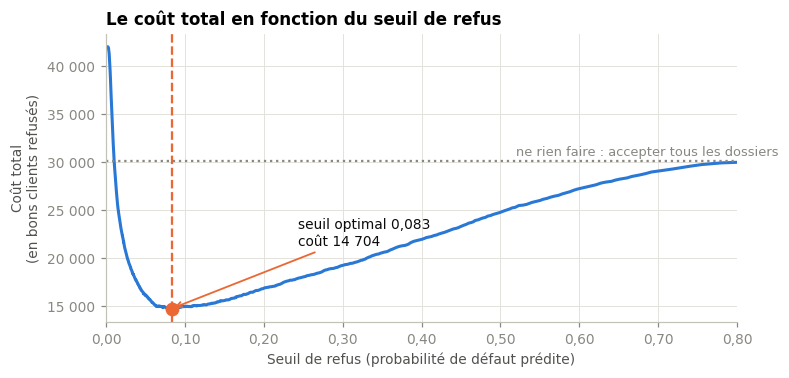

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.plot(courbe_cout["seuil"], courbe_cout["coût"], color=BLEU, lw=2)
ax.axvline(seuil_optimal, color=ORANGE, lw=1.5, ls="--")
ax.plot([seuil_optimal], [optimum["coût"]], "o", ms=8, color=ORANGE, zorder=3)

cout_rien = bilan(1.01)["coût"]
ax.axhline(cout_rien, color=GRIS, lw=1.5, ls=":")
ax.text(0.52, cout_rien * 1.02, "ne rien faire : accepter tous les dossiers",
        color=GRIS, fontsize=8.5)

ax.annotate(
    f"seuil optimal {seuil_optimal:.3f}\ncoût {optimum['coût']:,.0f}".replace(",", " ").replace(".", ","),
    xy=(seuil_optimal, optimum["coût"]),
    xytext=(seuil_optimal + 0.16, optimum["coût"] * 1.45),
    fontsize=9, color="#0b0b0b",
    arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.2),
)

ax.set_xlim(0, 0.8)
ax.set_xlabel("Seuil de refus (probabilité de défaut prédite)")
ax.set_ylabel("Coût total\n(en bons clients refusés)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ")))
ax.xaxis.set_major_formatter(virgule)
ax.grid(lw=0.6)
ax.set_axisbelow(True)
ax.set_title("Le coût total en fonction du seuil de refus")
save_fig(fig, "07_cout_par_seuil")
plt.show()

## 3. Ce que le modèle rapporte, en clair

Traduisons en euros pour donner un ordre de grandeur. Si un défaut coûte
**10 000 €** de capital perdu et un bon client refusé **1 000 €** de marge
manquée — mêmes proportions que l'hypothèse 1:10 — on obtient le tableau
suivant sur les 45 000 dossiers de validation.

In [9]:
COUT_DEFAUT, COUT_BON_CLIENT = 10_000, 1_000

en_euros = politiques.copy()
en_euros["coût (M€)"] = (
    en_euros["défauts manqués"] * COUT_DEFAUT
    + en_euros["bons clients refusés"] * COUT_BON_CLIENT
) / 1e6
reference = en_euros.loc["Accepter tout le monde", "coût (M€)"]
en_euros["économie (M€)"] = (reference - en_euros["coût (M€)"]).round(1)
en_euros[["défauts captés", "bons clients refusés", "coût (M€)", "économie (M€)"]].round(1)

,défauts captés,bons clients refusés,coût (M€),économie (M€)
politique,,,,
Accepter tout le monde,0,0,30.1,0.0
Refuser tout le monde,3008,41992,42.0,-11.9
"Modèle, seuil 0,083",2216,6784,14.7,15.4


## 4. Et si le ratio de coût était faux ?

L'hypothèse 1:10 n'est pas mesurée. La bonne pratique n'est pas de la défendre,
c'est de montrer ce qu'elle change — si la recommandation tient sur une large
plage de ratios, l'objection perd sa force.

In [10]:
sensibilite = []
for ratio in [2, 5, 10, 20, 30, 50]:
    courbe = pd.DataFrame([bilan(s, ratio=ratio) for s in seuils])
    meilleur = courbe.loc[courbe["coût"].idxmin()]
    sensibilite.append({
        "ratio de coût": f"1:{ratio}",
        "seuil optimal": meilleur["seuil"],
        "seuil théorique": 1 / (1 + ratio),
        "défauts captés": meilleur["défauts captés"] / N_DEFAUTS,
        "bons clients refusés": meilleur["bons clients refusés"] / N_SAINS,
    })

sensibilite = pd.DataFrame(sensibilite).set_index("ratio de coût")
sensibilite.style.format({
    "seuil optimal": "{:.3f}", "seuil théorique": "{:.3f}",
    "défauts captés": "{:.1%}", "bons clients refusés": "{:.1%}",
})

,seuil optimal,seuil théorique,défauts captés,bons clients refusés
ratio de coût,,,,
1:2,0.345,0.333,35.8%,2.6%
1:5,0.155,0.167,59.1%,7.9%
1:10,0.083,0.091,73.7%,16.2%
1:20,0.063,0.048,80.1%,21.3%
1:30,0.034,0.032,88.5%,35.5%
1:50,0.015,0.020,95.6%,56.5%


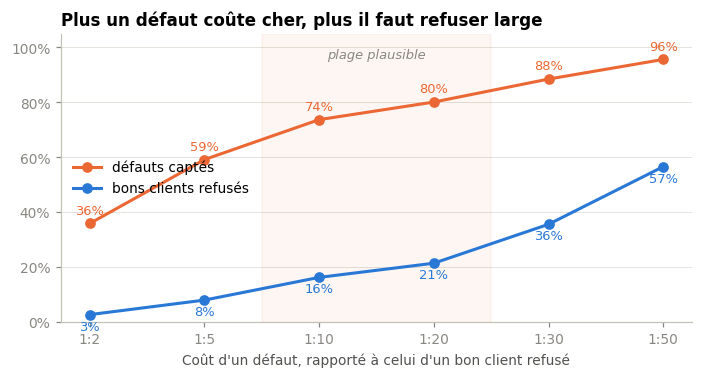

In [11]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
x = np.arange(len(sensibilite))

ax.plot(x, sensibilite["défauts captés"], marker="o", ms=6, lw=2, color=ORANGE,
        label="défauts captés")
ax.plot(x, sensibilite["bons clients refusés"], marker="o", ms=6, lw=2, color=BLEU,
        label="bons clients refusés")

for i, (capte, refuse) in enumerate(zip(sensibilite["défauts captés"],
                                        sensibilite["bons clients refusés"])):
    ax.text(i, capte + 0.035, f"{capte:.0%}", ha="center", fontsize=8.5, color=ORANGE)
    ax.text(i, refuse - 0.055, f"{refuse:.0%}", ha="center", fontsize=8.5, color=BLEU)

ax.axvspan(1.5, 3.5, color="#eb6834", alpha=0.06)
ax.text(2.5, 0.96, "plage plausible", ha="center", fontsize=8.5, color=GRIS, style="italic")

ax.set_xticks(x, sensibilite.index)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Coût d'un défaut, rapporté à celui d'un bon client refusé")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(frameon=False, loc="center left")
ax.grid(axis="y", lw=0.6)
ax.set_axisbelow(True)
ax.set_title("Plus un défaut coûte cher, plus il faut refuser large")
save_fig(fig, "08_sensibilite_ratio")
plt.show()

**Le résultat n'est pas celui qu'on aimerait présenter, et c'est précisément
pour cela qu'il faut le montrer.** La recommandation n'est pas robuste au
ratio de coût :

- à **1:5**, on capte 59 % des défauts en refusant 7,9 % des bons clients ;
- à **1:20**, on capte 80 % des défauts en refusant 21,3 % des bons clients.

Entre ces deux hypothèses, le nombre de bons clients écartés est **presque
triplé**. Ce n'est pas un détail de paramétrage : c'est la décision la plus
lourde de tout le projet, et elle ne se tranche pas avec des données, elle se
tranche avec la direction des risques.

Autrement dit, la question « combien coûte réellement un défaut chez nous ? »
mérite plus d'attention que tout le travail de modélisation qui précède. Le
modèle fournit le classement ; l'entreprise fournit l'arbitrage. Présenter le
seuil 1:10 comme une conclusion technique serait une faute.

On observe aussi que le seuil optimal empirique s'écarte davantage de la
théorie à 1:20 (0,064 contre 0,048 attendu) : la courbe de coût y est
particulièrement plate, donc son minimum est mal déterminé. Une raison de plus
de raisonner en plages plutôt qu'en valeur unique.

## 5. Pourquoi le modèle décide ce qu'il décide

Un score de crédit qu'on ne sait pas expliquer n'est pas déployable : le refus
doit pouvoir être justifié au client, et au régulateur. SHAP attribue à chaque
variable sa contribution à chaque prédiction.

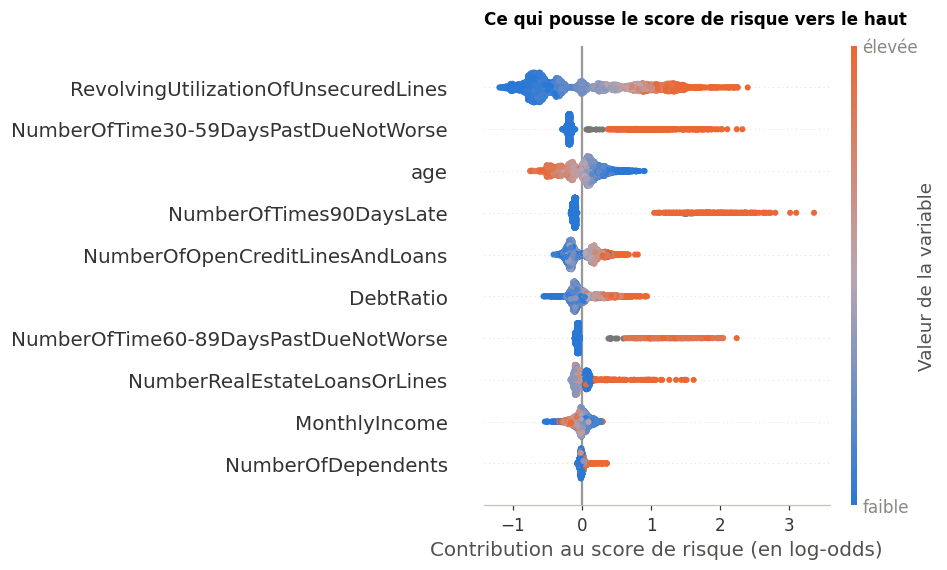

In [12]:
import shap
from matplotlib.colors import LinearSegmentedColormap
from shap.plots._labels import labels as libelles_shap

# SHAP est anglophone par défaut et impose sa palette rouge/bleu. On aligne
# les deux sur le reste du projet : les figures partiront dans les mêmes
# slides que les précédentes.
libelles_shap["VALUE"] = "Contribution au score de risque (en log-odds)"
libelles_shap["FEATURE_VALUE"] = "Valeur de la variable"
libelles_shap["FEATURE_VALUE_LOW"] = "faible"
libelles_shap["FEATURE_VALUE_HIGH"] = "élevée"

palette_projet = LinearSegmentedColormap.from_list("projet", [BLEU, "#b9a6b0", ORANGE])

echantillon = X_val.sample(4000, random_state=HASARD)
valeurs_shap = shap.TreeExplainer(modele).shap_values(echantillon)

shap.summary_plot(valeurs_shap, echantillon, show=False, max_display=10,
                  cmap=palette_projet, plot_size=(8.5, 5),
                  color_bar_label="Valeur de la variable")
fig = plt.gcf()
fig.set_facecolor("white")
fig.axes[0].set_title("Ce qui pousse le score de risque vers le haut",
                      loc="left", fontsize=11, fontweight="semibold", pad=14)
save_fig(fig, "09_shap")
plt.show()

Le classement confirme l'analyse par déciles du premier notebook : **taux
d'utilisation du crédit** en tête, puis les **incidents de paiement passés**,
puis l'**âge**. Deux méthodes indépendantes qui convergent, c'est un bon signe
de solidité.

Les couleurs donnent le sens de l'effet, et il est conforme à l'intuition
métier : une utilisation du crédit **élevée** pousse le score vers le haut,
un âge **faible** aussi. Les incidents passés forment un paquet dense très à
droite — peu de clients concernés, mais une contribution massive quand le cas
se présente.

**Les trois indicatrices que nous avons créées n'apparaissent pas dans les dix
premières variables.** Sur treize, elles occupent les trois dernières places.

C'est la troisième fois que ce constat revient par un chemin différent :
l'ablation ne leur trouvait aucun effet mesurable sur l'AUC, la comparaison
brut/nettoyé montrait que LightGBM se passait du nettoyage, et SHAP confirme
maintenant que le modèle ne s'en sert pas. Trois méthodes indépendantes qui
concordent : le point est acquis.

Ce n'est pas contradictoire avec le fait que les dossiers au code 96/98 fassent
54,6 % de défaut. Ils ne sont que 269 sur 150 000 : le signal est très fort
mais porte sur trop peu de dossiers pour peser en moyenne. **Un signal fort
n'est pas un signal important** — la distinction se perd souvent, et c'est
exactement ce que SHAP permet de trancher, puisqu'il mesure une contribution
moyenne et non une intensité.

Dernier rappel, parce que c'est le contresens le plus fréquent en restitution :
ces contributions sont en **log-odds**, pas en probabilité. Une contribution de
+1 ne signifie pas « +100 % de risque ».

## 6. Ce qu'il faut retenir pour la restitution

**Le modèle.** LightGBM sur données nettoyées, AUC de 0,867 en validation,
précision moyenne de 0,405 — six fois mieux que le hasard.

**La décision.** Avec l'hypothèse 1:10, le seuil optimal est de 0,083. Il
conduit à refuser 9 000 dossiers sur 45 000, ce qui capte **73,7 % des
défauts** au prix de **16,2 % des bons clients** écartés à tort. Un dossier
refusé sur quatre aurait effectivement fait défaut, contre un sur quinze si
l'on refusait au hasard.

**Le gain.** Le coût total passe de 30,1 M€ (accepter tout le monde) à
14,7 M€, soit **15,4 M€ économisés** sous les hypothèses de coût retenues.

**La réserve, à énoncer en premier et non en note de bas de page.** Le ratio
1:10 n'est pas mesuré. Entre 1:5 et 1:20, le nombre de bons clients refusés
triple. Le chiffrage ci-dessus n'a donc de valeur qu'accompagné de cette
hypothèse, et la première action recommandée n'est pas de déployer le modèle :
c'est d'établir ce ratio avec la direction des risques.

**Ce que le notebook ne couvre pas**, et qu'il faudrait traiter avant un
déploiement réel : la stabilité du modèle dans le temps, l'équité de ses
décisions entre catégories d'emprunteurs, et la mise en place d'un suivi de
dérive des données.